# Plots

In [1]:
%matplotlib inline
import os

# feiura
try:
    ORIGINAL
except NameError:
    ORIGINAL = os.getcwd()
    if ORIGINAL.strip("/").endswith("scenarios/main"):
        os.chdir("../../")

from easyvvuq.analysis.sc_analysis import SCAnalysisResults

from typing import cast

from src import machines
from src import programs
from src import energyuq
from src.util import plot, parser
from src.util.data import *


import matplotlib.pyplot as plt

/home/mmachado/HPC/energyuq/.venv/lib/python3.14/site-packages/chaospy/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
DAKOTA=False
EASY=True
result_set: dict[str, Result] = {}
qois = ["energy_uj", "time"]
energyuq.QOI = "energy_uj"
if DAKOTA:
    result_set["dakota"] = Result(parser.parse_dakota_file("pce_samples.dat"), qois)

if EASY:
    campaign_name = "energy"
    mach = machines.Glados
    # campaign, analysis = energyuq.load(programs.HPCG, mach, campaign_name, dir="hype_results/run_results/energy_8/")
    campaign, analysis = energyuq.load(programs.NONE, mach, campaign_name, dir="run_results/energy_25/")

    plot.init({
        "N_THREADS": limit(1, mach.max_threads),
        "CLK": limit(0, len(mach.freq) - 1),
        "AFF_DISTANCE": limit(0, len(mach.proc_bind) - 1),
        "PLACE_WIDE": limit(0, len(mach.places) - 1),
    })
    result_set["easyvvuq"] = EasyResult(
        campaign.get_collation_result(),
        qois,
        analysis,
        campaign,
        energyuq.get_sampler(campaign),
        cast(SCAnalysisResults, campaign.get_last_analysis())
    )



/home/mmachado/HPC/energyuq/.venv/lib/python3.14/site-packages/cerberus/validator.py:618: UserWarning: These types are defined both with a method and in the'types_mapping' property of this validator: {'integer'}
  warn(


## Which configurations consumed less energy or time in total

/home/mmachado/HPC/energyuq/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


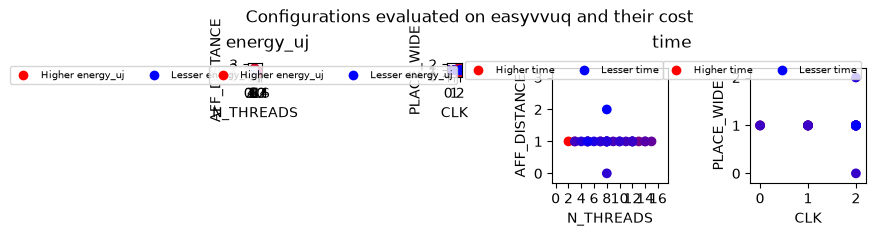

In [3]:
for name, result in result_set.items():
    fig = plt.figure(figsize=(8,8), layout="constrained")
    fig.suptitle(f"Configurations evaluated on {name} and their cost")
    fs = fig.subfigures(1, 2).flatten()
    c=0
    for qoi in qois:
        f = plot.plot_grid_2D_best(result, qoi, subfig=fs[c])
        f.suptitle(qoi)
        c += 1


In [4]:
import numpy as np
np.min(np.max(analysis.l_norm, 0))

1

## What is the difference between the best and worst configurations?

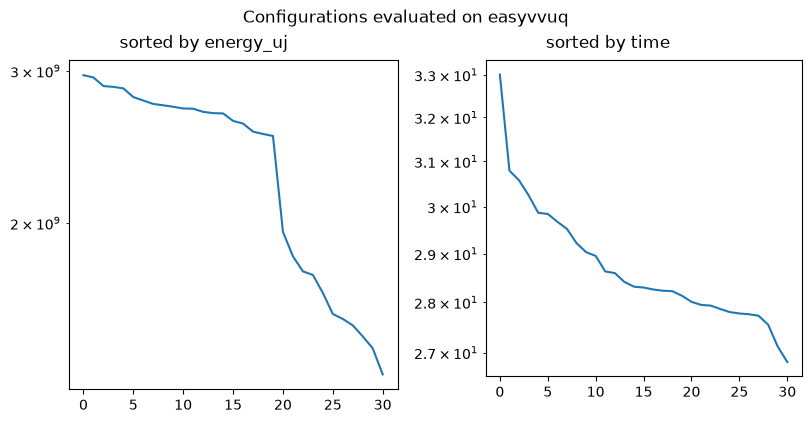

In [5]:
for name, result in result_set.items():
    fig = plt.figure(figsize=(8,8), layout="constrained")
    fig.suptitle(f"Configurations evaluated on {name}")
    fs = fig.subfigures(1, 2) #could be more that 2
    c=0
    for qoi in qois:
        if qoi not in result.qois:
            continue
        f = plot.plot_sorted(result, qoi, subfig=fs[c])
        f.suptitle(f'sorted by {qoi}')
        c+=1

## View of the resulting energy usage and time against each parameter

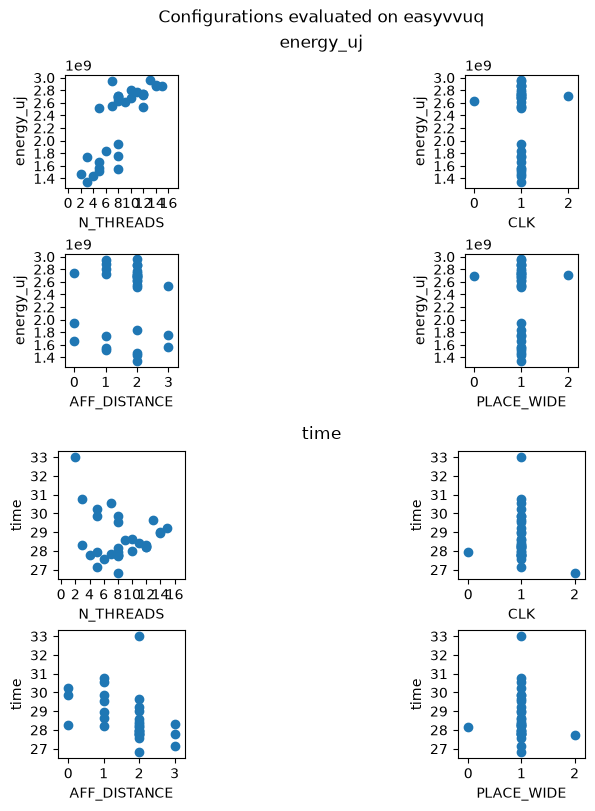

In [6]:

for name, result in result_set.items():
    fig = plt.figure(figsize=(8,8), layout="constrained")
    fig.suptitle(f"Configurations evaluated on {name}")
    fs = fig.subfigures(2, 1) #could be more that 2
    c=0
    for qoi in qois:
        if qoi not in result.qois:
            continue
        f = plot.plot_2D_single_dimension(result, qoi, subfig=fs[c])
        f.suptitle(qoi)
        c+=1
    fig.align_titles()

# EasyVVUQ plots
The following could be generated only from easyvvuq, for now

## First order sobol indices and decomposition treemap

ZeroDivisionError: division by zero

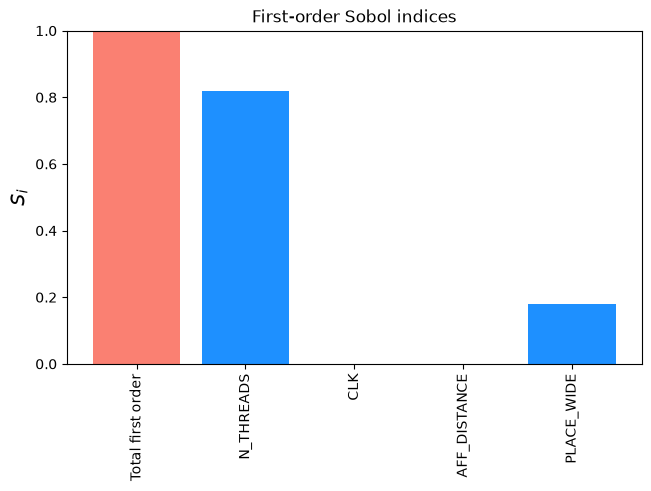

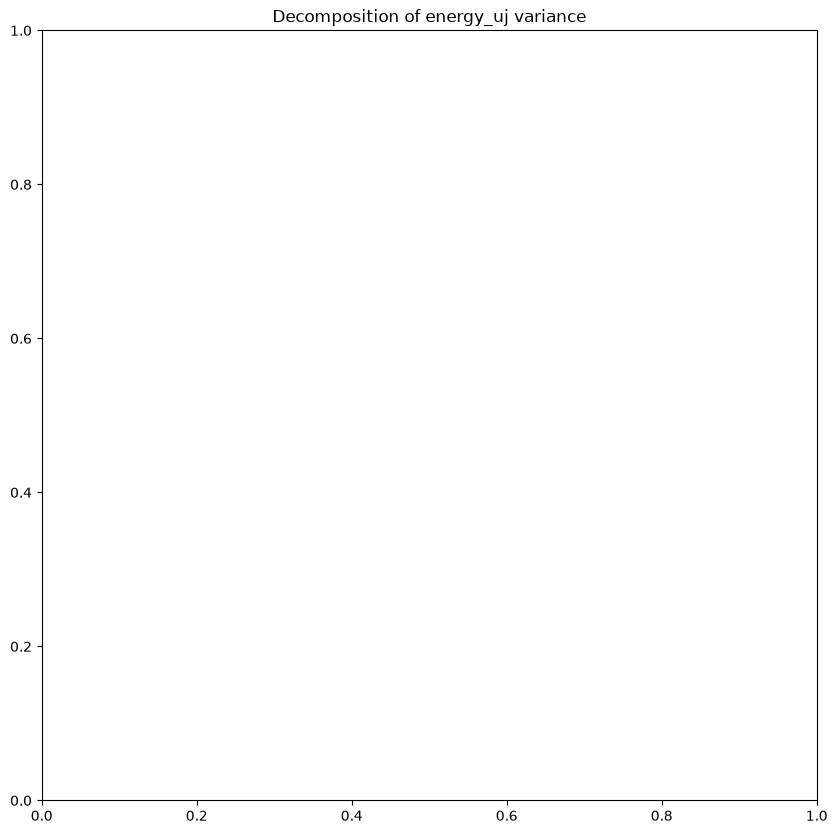

In [7]:

for name, result in result_set.items():
    if not isinstance(result, EasyResult):
        continue
    plot.plot_sobols1(result, energyuq.QOI)
    result.results.plot_sobols_treemap(energyuq.QOI, figsize=(10, 10))
    plt.axis('off')

## Adaptation table, histogram and errors

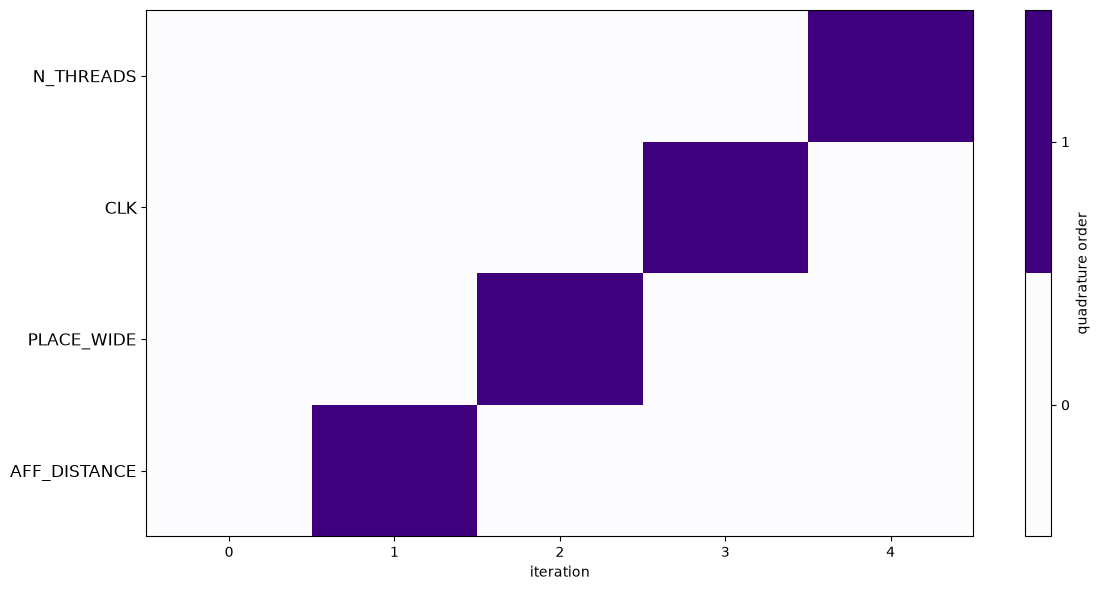

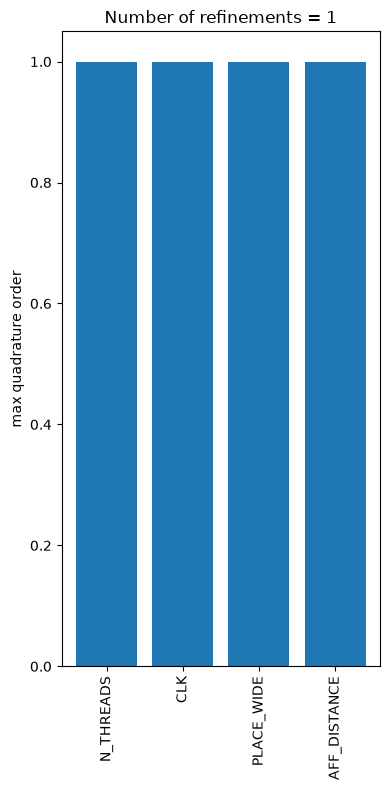

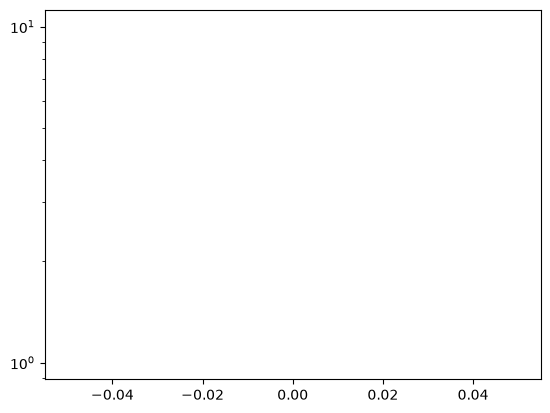

In [ ]:
for name, result in result_set.items():
    if not isinstance(result, EasyResult):
        continue
    result.analysis.adaptation_table()
    result.analysis.adaptation_histogram()
    plt.semilogy(result.analysis.get_adaptation_errors())

## Uncertainty amplification and stat convergence

In [ ]:
for name, result in result_set.items():
    if not isinstance(result, EasyResult):
        continue
    result.analysis.get_uncertainty_amplification(energyuq.QOI)
    result.analysis.plot_stat_convergence()

-----------------
Mean CV input = 73.0169 %
Mean CV output = 23.9563 %
Uncertainty amplification factor = 0.2396/0.7302 = 0.3281
-----------------


In [ ]:
mean_f, var_f = analysis.get_moments(energyuq.QOI)
std_f = np.sqrt(var_f)
CV_out = std_f / mean_f
mean_f, var_f, std_f, CV_out

mean_f = analysis.quadrature(energyuq.QOI)
# display(analysis.samples[energyuq.QOI])
# display(mean_f)
variance_samples = [(sample - mean_f)**2 for sample in analysis.samples[energyuq.QOI]]
analysis.quadrature(energyuq.QOI, variance_samples)
[v for v in variance_samples if v < 0]
analysis.get_moments(energyuq.QOI)
[f"{a:.3f}" for a in var_f.tolist()]

['301398121437981568.000']